#### 1. Monthly Revenue Line Chart
#### Using order_date and revenue:
#### • Convert order_date to datetime.
#### • Calculate total revenue for each month.
#### • Create a line chart.
#### • Add:
#### o Title
#### o X-axis label
#### o Y-axis label
#### o Grid
#### o Markers

#### Commands/concepts: plt.plot(), plt.title(), plt.xlabel(), plt.ylabel(), plt.grid()

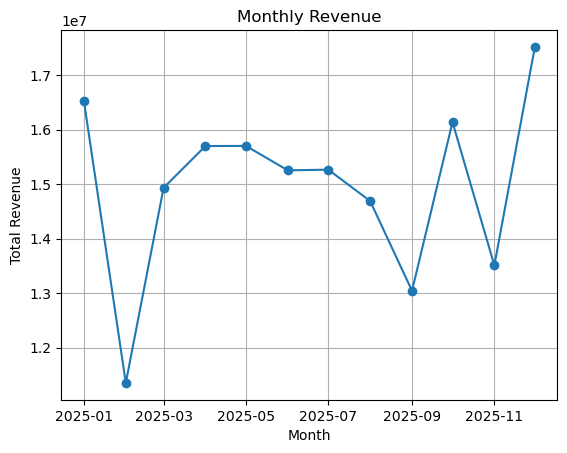

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_messy_sales_data.csv")


df['order_date'] = pd.to_datetime(df['order_date'])

monthly_revenue = df.groupby(
    df['order_date'].dt.to_period('M')
)['revenue'].sum()

monthly_revenue.index = monthly_revenue.index.to_timestamp()


plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')


plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)

#### 2. Monthly Profit Line Chart
#### Create a line chart showing monthly Profit.
#### Requirements:
#### • Use a different line style.
#### • Add markers.
#### • Add a legend.
#### • Display the value of the highest-profit month using annotate().
#### Commands/concepts: plt.plot(), plt.legend(), plt.annotate()

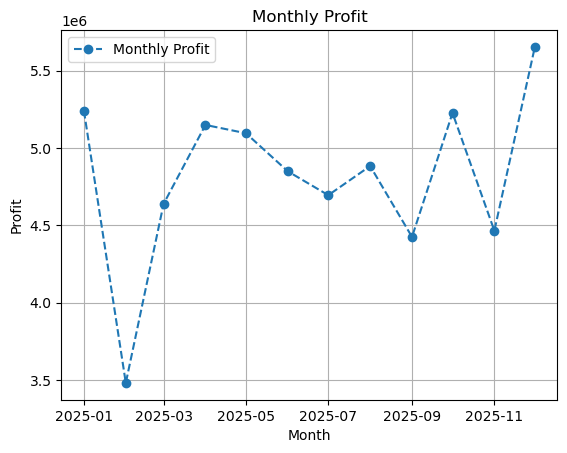

In [14]:
df['order_date'] = pd.to_datetime(df['order_date'])

monthly_profit = df.groupby(
    df['order_date'].dt.to_period('M')
)['profit'].sum()


monthly_profit.index = monthly_profit.index.to_timestamp()


highest_month = monthly_profit.idxmax()


highest_month  = monthly_profit.max()

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    linestyle='--',
    marker='o',
    label='Monthly Profit'
)

plt.title('Monthly Profit')

plt.xlabel('Month')

plt.ylabel('Profit')

plt.grid(True)

plt.legend()

plt.annotate(
    f'Highest Profit: {highest_profit:.2f}',
    xy=(highest_month, highest_profit),
    xytext=(10, 20),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)


plt.show()

#### 3. Revenue by Product Category — Bar Chart
#### Calculate total revenue for each product_category.
#### Create a bar chart.
#### Requirements:
#### • X-axis → Product Category
#### • Y-axis → Revenue
#### • Add title and labels.
#### • Display the revenue value above each bar.
#### Commands/concepts: plt.bar(), plt.text()

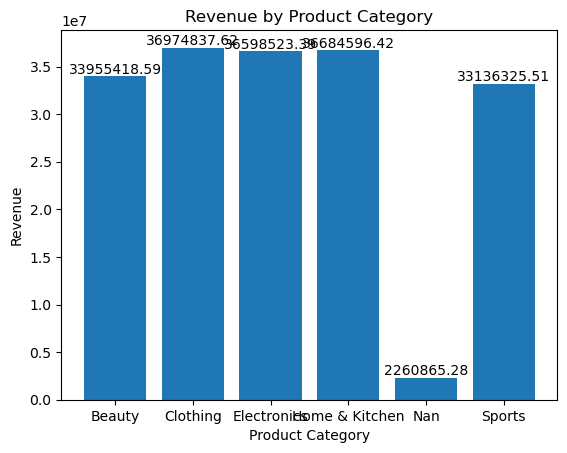

In [21]:
category_revenue = df.groupby('product_category')['revenue'].sum()


plt.bar(category_revenue.index, category_revenue.values)

plt.title('Revenue by Product Category')

plt.xlabel('Product Category')

plt.ylabel('Revenue')

for i, value in enumerate(category_revenue.values):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')

plt.show()

#### 4. Profit by City — Horizontal Bar Chart
#### Calculate total profit for each city.
#### Create a horizontal bar chart.
#### Requirements:
#### • Sort cities by profit.
#### • Show the highest-profit city first.
#### • Add title and axis labels.
#### Commands/concepts: plt.barh(), sort_values()

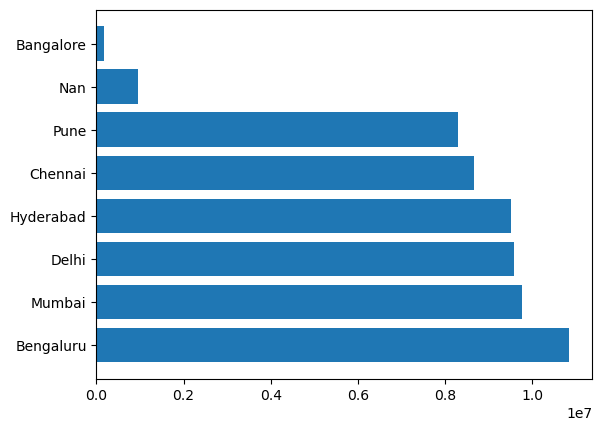

In [23]:
city_profit = df.groupby('city')['profit'].sum()

city_profit = city_profit.sort_values(ascending=False)

plt.barh(city_profit.index, city_profit.values)

plt.show()

#### 5. Customer Age Histogram
#### Create a histogram of the age column.
#### Requirements:
#### • Use 10 bins.
#### • Add title.
#### • Add X/Y labels.
#### • Add grid.
#### • Add a vertical line showing the median age.
#### Commands/concepts: plt.hist(), plt.axvline()

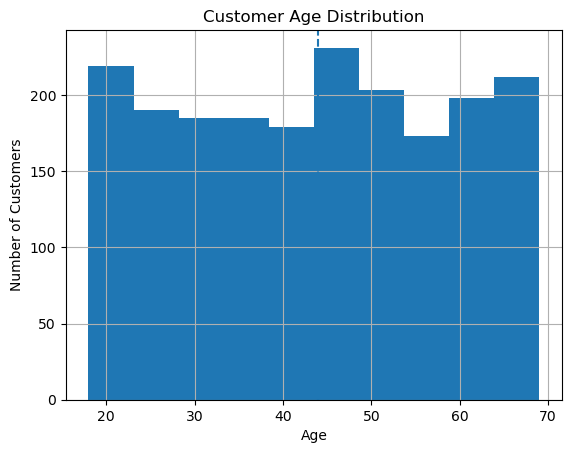

In [25]:
median_age = df['age'].median()

plt.hist(df['age'].dropna(), bins=10)

plt.title('Customer Age Distribution')

plt.xlabel('Age')

plt.ylabel('Number of Customers')

plt.grid(True)

plt.axvline(median_age, linestyle='--',
            label=f'Median Age: {median_age:.0f}')

plt.show()

#### 6. Revenue Distribution Histogram
#### Create a histogram showing the distribution of revenue.
#### Requirements:
#### • Use 20 bins.
#### • Add transparency using alpha.
#### • Add grid.
#### • Add mean and median lines.
#### • Add a legend.
#### Commands/concepts:
#### plt.hist()
#### plt.axvline()
#### plt.legend()